In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

data=pd.read_csv("/kaggle/input/dataset1/final_depression_dataset_1.csv")
data

,Name,Gender,Age,City,Working Professional or Student,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,Pooja,Female,37,Ghaziabad,Working Professional,Teacher,NaN,2.0,NaN,NaN,4.0,7-8 hours,Moderate,MA,No,6,2,No,No
1,Reyansh,Male,60,Kalyan,Working Professional,Financial Analyst,NaN,4.0,NaN,NaN,3.0,5-6 hours,Unhealthy,B.Com,Yes,0,4,Yes,No
2,Manvi,Female,42,Bhopal,Working Professional,Teacher,NaN,2.0,NaN,NaN,3.0,5-6 hours,Moderate,M.Com,No,0,2,No,No
3,Isha,Female,44,Thane,Working Professional,Teacher,NaN,3.0,NaN,NaN,5.0,7-8 hours,Healthy,MD,Yes,1,2,Yes,No
4,Aarav,Male,48,Indore,Working Professional,UX/UI Designer,NaN,4.0,NaN,NaN,3.0,7-8 hours,Moderate,BE,Yes,6,5,Yes,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2551,Raghavendra,Male,25,Bangalore,Working Professional,Consultant,NaN,1.0,NaN,NaN,5.0,5-6 hours,Healthy,BBA,Yes,12,3,Yes,No
2552,Pihu,Female,23,Pune,Working Professional,Teacher,NaN,3.0,NaN,NaN,1.0,Less than 5 hours,Moderate,MA,Yes,8,3,No,Yes
2553,Sara,Female,24,Srinagar,Working Professional,HR Manager,NaN,1.0,NaN,NaN,4.0,Less than 5 hours,Moderate,BA,Yes,4,4,No,No
2554,Eshita,Female,56,Bangalore,Working Professional,Business Analyst,NaN,2.0,NaN,NaN,3.0,7-8 hours,Healthy,BBA,No,4,5,Yes,No


In [2]:
import pandas as pd

def print_nan_counts(csv_file):
    """
    Print the count of NaN values column-wise for all columns except the last one in a CSV file.

    :param csv_file: Path to the CSV file.
    """
    # Read the CSV file into a DataFrame
    df = pd.read_csv(csv_file)

    # Get all column names except the last one
    columns_to_check = df.columns[:-1]

    # Iterate through the selected columns and count NaN values
    for column in columns_to_check:
        nan_count = df[column].isna().sum()
        print(f"Column '{column}': {nan_count} NaN values")

# Example usage
csv_file_path = "/kaggle/input/dataset1/final_depression_dataset_1.csv"  # Replace with the path to your CSV file
print_nan_counts(csv_file_path)


Column 'Name': 0 NaN values
Column 'Gender': 0 NaN values
Column 'Age': 0 NaN values
Column 'City': 0 NaN values
Column 'Working Professional or Student': 0 NaN values
Column 'Profession': 673 NaN values
Column 'Academic Pressure': 2054 NaN values
Column 'Work Pressure': 502 NaN values
Column 'CGPA': 2054 NaN values
Column 'Study Satisfaction': 2054 NaN values
Column 'Job Satisfaction': 502 NaN values
Column 'Sleep Duration': 0 NaN values
Column 'Dietary Habits': 0 NaN values
Column 'Degree': 0 NaN values
Column 'Have you ever had suicidal thoughts ?': 0 NaN values
Column 'Work/Study Hours': 0 NaN values
Column 'Financial Stress': 0 NaN values
Column 'Family History of Mental Illness': 0 NaN values


In [4]:
import pandas as pd

def drop_columns(df):
    """
    Drops specific columns from the DataFrame.

    :param df: Input DataFrame.
    :return: DataFrame with the specified columns removed.
    """
    columns_to_drop = [
        'Academic Pressure',
        'Work Pressure',
        'CGPA',
        'Study Satisfaction',
        'Job Satisfaction',
        'Profession',
        'Name',
        'City',
        'Gender' ,
        'Profession',
        'Sleep Duration',
        'Dietary Habits',
        'Degree',
        'Family History of Mental Illness' 
    ]

    # Drop the specified columns
    df = df.drop(columns=columns_to_drop, errors='ignore')  # `errors='ignore'` prevents errors if a column doesn't exist

    return df

# Example usage
# Assume the DataFrame `df` is already loaded
df = pd.read_csv('/kaggle/input/dataset1/final_depression_dataset_1.csv')  # Uncomment and replace with your file if needed

# Drop the specified columns
df = drop_columns(df)

# Print the updated DataFrame
df


,Age,Working Professional or Student,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Depression
0,37,Working Professional,No,6,2,No
1,60,Working Professional,Yes,0,4,No
2,42,Working Professional,No,0,2,No
3,44,Working Professional,Yes,1,2,No
4,48,Working Professional,Yes,6,5,No
...,...,...,...,...,...,...
2551,25,Working Professional,Yes,12,3,No
2552,23,Working Professional,Yes,8,3,Yes
2553,24,Working Professional,Yes,4,4,No
2554,56,Working Professional,No,4,5,No


In [5]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

columns_to_encode= [ 'Working Professional or Student',  'Have you ever had suicidal thoughts ?']  # Columns to encode

label_encoder = LabelEncoder()
for column in columns_to_encode:
        if column in df.columns:
            df[column] = label_encoder.fit_transform(df[column])

df

,Age,Working Professional or Student,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Depression
0,37,1,0,6,2,No
1,60,1,1,0,4,No
2,42,1,0,0,2,No
3,44,1,1,1,2,No
4,48,1,1,6,5,No
...,...,...,...,...,...,...
2551,25,1,1,12,3,No
2552,23,1,1,8,3,Yes
2553,24,1,1,4,4,No
2554,56,1,0,4,5,No


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report

X = df.drop(columns=['Depression'])  # Features
y = df['Depression']  # Target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [7]:
#Creating the decision tree model
dt_model = DecisionTreeClassifier(random_state=42)

In [8]:
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [9]:
# Predict on the test set
y_pred = dt_model.predict(X_test)


Accuracy: 0.8722294654498044
Classification Report:
               precision    recall  f1-score   support

          No       0.93      0.92      0.92       647
         Yes       0.59      0.61      0.60       120

    accuracy                           0.87       767
   macro avg       0.76      0.76      0.76       767
weighted avg       0.87      0.87      0.87       767



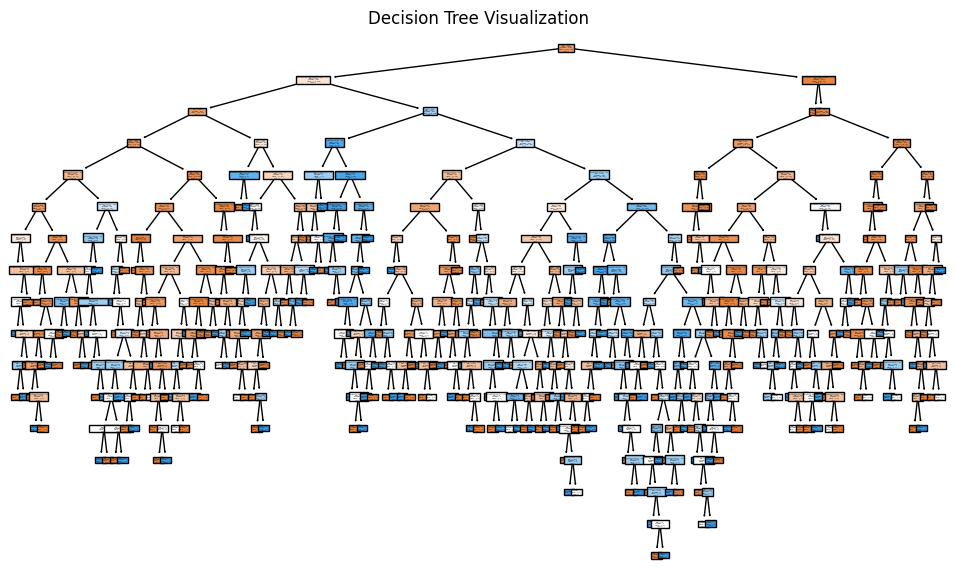

In [10]:
# Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

# Visualize the Decision Tree
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 7))
plot_tree(dt_model, feature_names=X.columns, class_names=str(y.unique()), filled=True)
plt.title("Decision Tree Visualization")
plt.show()

In [22]:
def predict_depression(input_data, model):
    """
    Predict depression status using the trained model and top features.
    
    Args:
    - input_data (dict): Dictionary containing feature values for prediction.
    - model (object): Trained model for prediction.
    - top_features (list): List of top features used by the model.
    
    Returns:
    - str: Prediction result ("Depression" or "No Depression").
    """
    # Convert the input data dictionary into a DataFrame
    input_df = pd.DataFrame([input_data])
    
    # Ensure the input contains all required features and matches the model's format
    #missing_features = set(top_features) - set(input_data.keys())
    #if missing_features:
        #raise ValueError(f"Missing required features for prediction: {missing_features}")
    
    # Predict using the trained model
    prediction = model.predict(input_df)
    
    # Return result
    return "Depression" if prediction[0] == 1 else "No Depression"

# Example input
input_data = {
    "Gender": 0, 
    "Age" : 22,
    "Working Professional or Student" : 0,
    "Sleep Duration" : 1,
    "Dietary Habits" : 2,
    "Degree" : 18,
    "Have you ever had suicidal thoughts ?": 1,
    "Work/Study Hours": 12,
    "Financial Stress": 12, 
    "Family History of Mental Illness" : 1
}

# Predict using the trained model and updated top 5 features
try:
    prediction = predict_depression(input_data, dt_model)
    print(f"Prediction: {prediction}")
except ValueError as e:
    print(f"Error: {e}")


Prediction: Depression


,Gender,Age,Working Professional or Student,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness
548,0,31,1,2,0,26,0,9,2,1
2308,1,43,1,1,2,4,1,6,3,1
2004,1,44,1,0,2,7,0,0,3,1
1304,1,36,1,1,1,12,0,10,3,1
306,0,55,1,3,2,26,0,5,2,1
...,...,...,...,...,...,...,...,...,...,...
1638,1,47,1,0,2,10,1,3,5,1
1095,0,48,1,0,1,21,1,2,1,0
1130,0,29,0,0,0,23,0,9,1,0
1294,1,34,0,0,0,22,0,7,1,0
